# 04 — MFCC feature representation

In the previous notebooks, we explored:

```text
waveform → STFT → spectrogram → mel-spectrogram → log-mel-spectrogram
```

In this notebook, we will study **Mel-Frequency Cepstral Coefficients (MFCCs)**.

MFCCs are widely used audio features because they provide a compact numerical representation of the spectral shape of an audio signal.

The main idea is:

```text
log-mel spectrum → Discrete Cosine Transform → MFCCs
```

We will focus on the intuition, visualization, and practical computation of MFCCs using `librosa`.

## Learning goals

By the end of this notebook, students should be able to explain the following sequence:

```text
audio signal
    ↓
STFT
    ↓
mel-spectrogram
    ↓
log-mel-spectrogram
    ↓
DCT along the mel-frequency axis
    ↓
MFCCs
    ↓
feature vectors for machine learning
```

The central idea is:

> MFCCs are compact descriptors obtained by applying the Discrete Cosine Transform to log-mel spectra.

We will build the intuition step by step:

1. Recall the log-mel-spectrogram.
2. Inspect one log-mel frame.
3. Understand slow and fast variations across mel bands.
4. Introduce the DCT as a way to describe those variations.
5. Compute MFCCs using `librosa`.
6. Summarize MFCCs as tabular features for machine learning.

## Imports

In [1]:
from pathlib import Path

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Audio, display
from scipy.fft import dct, idct
from tqdm import tqdm

## Project paths and metadata

This notebook assumes that the ESC-50 subset has already been prepared.

If the metadata file does not exist, run the following scripts from the project root:

```bash
python scripts/01_download_esc50.py
python scripts/02_prepare_subset.py
```

In [2]:
PROJECT_ROOT = Path.cwd()

# If the notebook is launched from the notebooks folder,
# move one level up to the project root.
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SUBSET_METADATA = PROJECT_ROOT / "data" / "processed" / "esc50_subset" / "esc50_subset_metadata.csv"

print("Project root:", PROJECT_ROOT)
print("Subset metadata:", SUBSET_METADATA)
print("Metadata exists:", SUBSET_METADATA.exists())

Project root: /Users/vpoblete/Documents/20230208_vpoblete/20260620_info343_classes/audio-data-mining-class
Subset metadata: /Users/vpoblete/Documents/20230208_vpoblete/20260620_info343_classes/audio-data-mining-class/data/processed/esc50_subset/esc50_subset_metadata.csv
Metadata exists: True


In [3]:
import sys

SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from plot_config import (
    apply_plot_style,
    clean_axes,
    GRAYSCALE,
    ACCENT,
    FIGSIZE_WIDE,
    FIGSIZE_TALL,
    DPI,
)

apply_plot_style()

print("Plot style loaded from:", SRC_DIR / "plot_config.py")

Plot style loaded from: /Users/vpoblete/Documents/20230208_vpoblete/20260620_info343_classes/audio-data-mining-class/src/plot_config.py


## Plot style utilities

To keep the notebook concise, plotting style and reusable plotting functions are stored in:

```text
src/plot_config.py
```

This keeps the notebook focused on audio concepts rather than repeated plotting code.

In [4]:
import sys

SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from plot_config import (
    apply_plot_style,
    plot_selected_mel_filters,
    plot_mel_filter_bank_matrix,
)

apply_plot_style()

In [5]:
metadata = pd.read_csv(SUBSET_METADATA)

print("Number of audio files:", len(metadata))
print("Number of classes:", metadata["category"].nunique())

metadata.head()

Number of audio files: 80
Number of classes: 8


,filename,fold,target,category,esc10,src_file,take,subset_audio_path
0,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A,data/processed/esc50_subset/audio/1-100038-A-1...
1,1-34495-A-14.wav,1,14,chirping_birds,False,34495,A,data/processed/esc50_subset/audio/1-34495-A-14...
2,1-34497-A-14.wav,1,14,chirping_birds,False,34497,A,data/processed/esc50_subset/audio/1-34497-A-14...
3,1-38559-A-14.wav,1,14,chirping_birds,False,38559,A,data/processed/esc50_subset/audio/1-38559-A-14...
4,1-38560-A-14.wav,1,14,chirping_birds,False,38560,A,data/processed/esc50_subset/audio/1-38560-A-14...


## Select one audio example

We will start with one example from the ESC-50 subset.

You can change `selected_category` to explore other classes.

In [6]:
selected_category = "chirping_birds" # "sneezing"

example = metadata[metadata["category"] == selected_category].iloc[0]
audio_path = PROJECT_ROOT / example["subset_audio_path"]

y, sr = librosa.load(audio_path, sr=None, mono=True)

print("Selected category:", selected_category)
print("Filename:", example["filename"])
print("Sampling rate:", sr, "Hz")
print("Duration:", librosa.get_duration(y=y, sr=sr), "seconds")

display(Audio(y, rate=sr))

Selected category: chirping_birds
Filename: 1-100038-A-14.wav
Sampling rate: 44100 Hz
Duration: 5.0 seconds


## Bridge from notebook 03 to notebook 04

In the previous notebook, we built the following representation:

```text
STFT spectrogram
    ↓
mel filter bank
    ↓
mel-spectrogram
    ↓
log-mel-spectrogram
```

The log-mel-spectrogram is already a useful image-like representation.

In this notebook, we go one step further:

```text
log-mel-spectrogram
    ↓
DCT
    ↓
MFCCs
```

The purpose of MFCCs is to describe the broad shape of the log-mel spectrum using a small number of coefficients.

## From log-mel spectrograms to MFCCs

A log-mel-spectrogram describes how energy is distributed across mel bands over time.

For one short-time frame, we can think of the log-mel spectrum as a vector:

$$
\mathbf{s}_t =
\begin{bmatrix}
s_{1,t} \\
s_{2,t} \\
\vdots \\
s_{M,t}
\end{bmatrix}
$$

where \(M\) is the number of mel bands.

MFCCs are obtained by applying the Discrete Cosine Transform (DCT) to this vector along the mel-frequency axis:

```text
one log-mel frame
    ↓
DCT across mel bands
    ↓
MFCC coefficients for that frame
```

Repeating this for every frame gives a time-varying MFCC representation.

## Compute a log-mel-spectrogram

We first compute the mel-spectrogram and then convert it to a logarithmic decibel scale.

In [7]:
n_fft = 2048
hop_length = 512
n_mels = 64

mel_spectrogram = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_fft=n_fft,
    hop_length=hop_length,
    n_mels=n_mels,
    power=2.0,
)

log_mel_spectrogram = librosa.power_to_db(mel_spectrogram, ref=np.max)

print("Mel-spectrogram shape:", mel_spectrogram.shape)
print("Log-mel-spectrogram shape:", log_mel_spectrogram.shape)

Mel-spectrogram shape: (64, 431)
Log-mel-spectrogram shape: (64, 431)


## Mel filter bank used for the MFCC computation

In the previous cell, we used:

```python
n_mels = 64
```

This means that the power spectrum is projected onto **40 mel bands** using a triangular mel filter bank.

Each filter corresponds to one mel band.  
The filter bank maps FFT frequency bins into a smaller number of perceptually motivated frequency bands.

In this section, we visualize the actual mel filter bank used in the computation.

In [8]:
# Mel filter bank used to compute the mel-spectrogram

mel_filter_bank = librosa.filters.mel(
    sr=sr,
    n_fft=n_fft,
    n_mels=n_mels,
    fmin=0,
    fmax=sr / 2,
    norm="slaney",
)

fft_frequencies = librosa.fft_frequencies(sr=sr, n_fft=n_fft)

print("Mel filter bank shape:", mel_filter_bank.shape)
print("Number of mel filters:", mel_filter_bank.shape[0])
print("Number of FFT frequency bins:", mel_filter_bank.shape[1])

Mel filter bank shape: (64, 1025)
Number of mel filters: 64
Number of FFT frequency bins: 1025


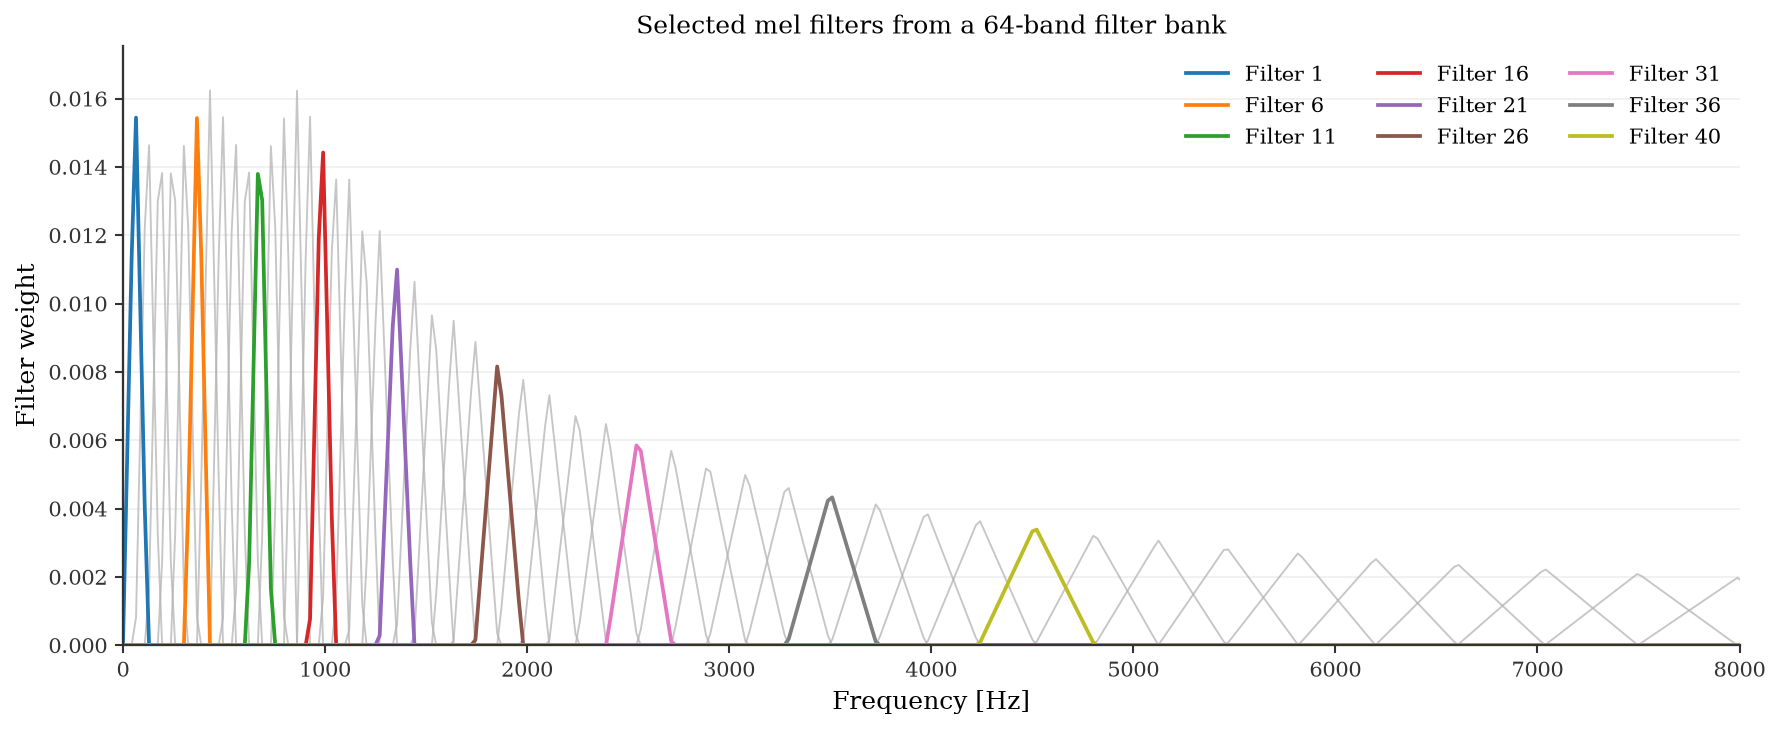

In [9]:
plot_selected_mel_filters(
    fft_frequencies=fft_frequencies,
    mel_filter_bank=mel_filter_bank,
    selected_filters=[0, 5, 10, 15, 20, 25, 30, 35, 39],
    xlim=(0, 8000),
)

We use norm="slaney", the default in librosa, which normalizes the triangular filters by their bandwidth. This makes the filter bank more balanced for feature extraction.

### Interpretation

The light gray curves show all 64 triangular mel filters.

A few filters are highlighted to make the structure easier to read.

The filters are narrow and densely spaced at low frequencies.  
As frequency increases, the filters become wider and more separated.

This reflects the mel-scale idea: lower frequencies receive more resolution, while higher frequencies are represented more coarsely.

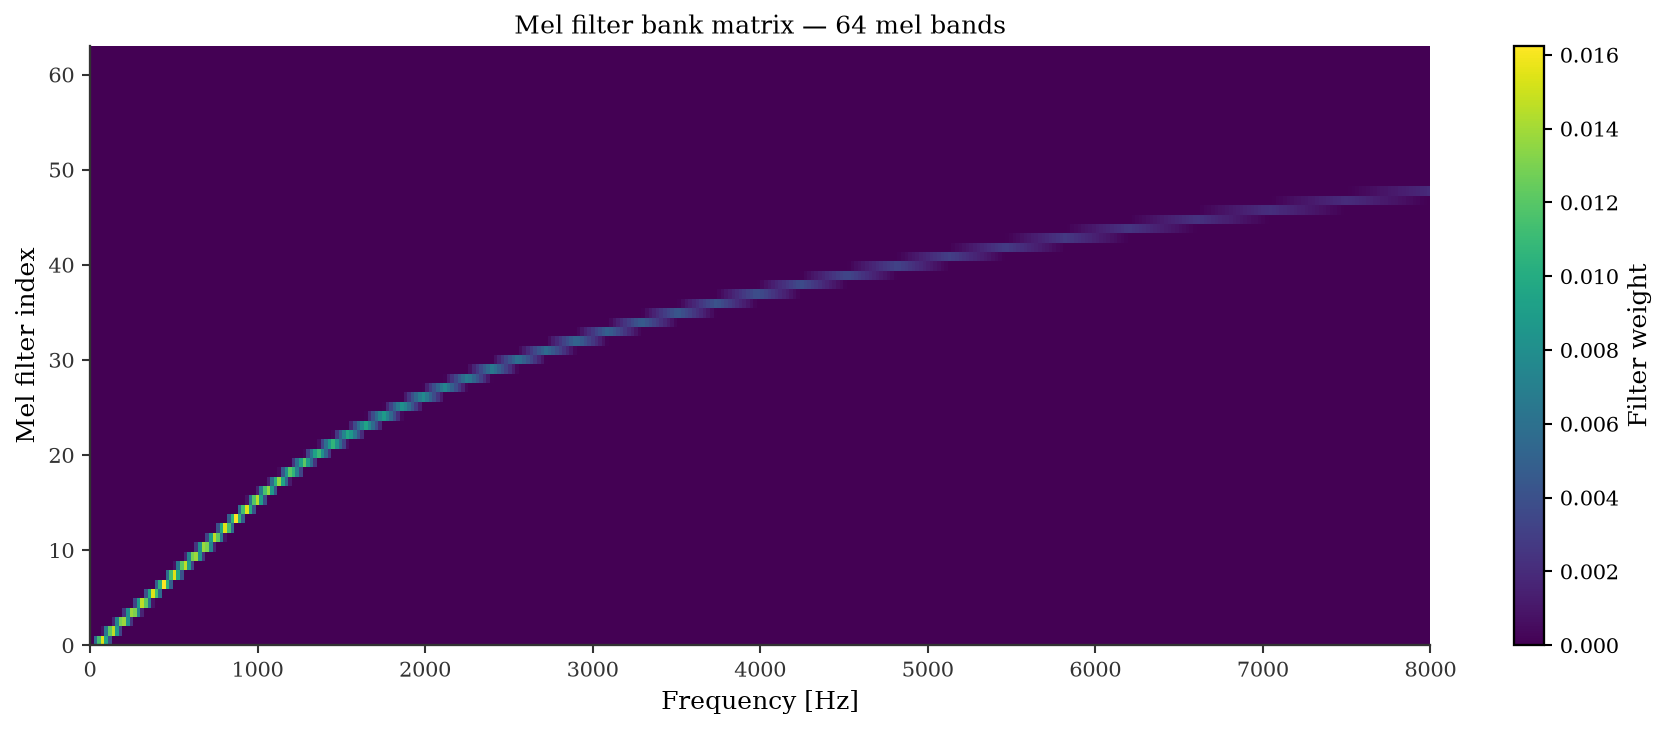

In [10]:
plot_mel_filter_bank_matrix(
    mel_filter_bank=mel_filter_bank,
    sr=sr,
    xlim=(0, 8000),
)

### Matrix interpretation

The mel filter bank is a matrix.

```text
rows    → mel filters
columns → FFT frequency bins
values  → filter weights
```

In this example, the matrix has 64 rows because we set `n_mels = 64`.

Each row is one triangular filter.  
When the filter bank is applied to the power spectrum, each mel band computes a weighted sum of spectral energy over a frequency region.

### Looking inside the mel filter bank matrix

To make the matrix interpretation more concrete, we can inspect a small numerical block of the mel filter bank.

The full matrix may be large. For example, with `n_mels = 64` and `n_fft = 2048`, its shape is:

```text
64 × 1025
```

Below we show only the first few rows and columns.

Most values near the beginning are zero because each triangular filter only has non-zero weights over a limited frequency region.

In [11]:
# mel_filter_bank_preview
# Inspect a small numerical block of the mel filter bank matrix.

preview_rows = 6
preview_columns = 16

mel_filter_bank_preview = pd.DataFrame(
    mel_filter_bank[:preview_rows, :preview_columns],
    index=[f"mel_filter_{i}" for i in range(preview_rows)],
    columns=[f"bin_{j}" for j in range(preview_columns)],
)

mel_filter_bank_preview.round(6)

,bin_0,bin_1,bin_2,bin_3,bin_4,bin_5,bin_6,bin_7,bin_8,bin_9,bin_10,bin_11,bin_12,bin_13,bin_14,bin_15
mel_filter_0,0.0,0.005688,0.011375,0.015441,0.009754,0.004066,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
mel_filter_1,0.0,0.000000,0.000000,0.000811,0.006498,0.012186,0.014631,0.008943,0.003256,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
mel_filter_2,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.001621,0.007309,0.012996,0.013820,0.008133,0.002445,0.000000,0.000000,0.000000,0.000000
mel_filter_3,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002432,0.008119,0.013807,0.013010,0.007322,0.001635,0.000000
mel_filter_4,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.003242,0.008930,0.014617,0.012199
mel_filter_5,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.004053


The table above shows only the first FFT bins.

A more informative view is to show, for the first few mel filters, which FFT bins actually receive non-zero weights.

In [12]:
# For each of the first few mel filters, show the FFT-bin range
# where the filter has non-zero weights.

rows = []

for filter_index in range(6):
    nonzero_bins = np.flatnonzero(mel_filter_bank[filter_index] > 0)

    if len(nonzero_bins) == 0:
        rows.append({
            "mel_filter": filter_index,
            "first_nonzero_bin": None,
            "last_nonzero_bin": None,
            "first_frequency_hz": None,
            "last_frequency_hz": None,
            "max_weight": mel_filter_bank[filter_index].max(),
        })
    else:
        first_bin = nonzero_bins[0]
        last_bin = nonzero_bins[-1]

        rows.append({
            "mel_filter": filter_index,
            "first_nonzero_bin": first_bin,
            "last_nonzero_bin": last_bin,
            "first_frequency_hz": fft_frequencies[first_bin],
            "last_frequency_hz": fft_frequencies[last_bin],
            "max_weight": mel_filter_bank[filter_index].max(),
        })

nonzero_summary = pd.DataFrame(rows)
nonzero_summary.round(6)

,mel_filter,first_nonzero_bin,last_nonzero_bin,first_frequency_hz,last_frequency_hz,max_weight
0,0,1,5,21.533203,107.666016,0.015441
1,1,3,8,64.599609,172.265625,0.014631
2,2,6,11,129.199219,236.865234,0.013820
3,3,9,14,193.798828,301.464844,0.013807
4,4,12,17,258.398438,366.064453,0.014617
5,5,15,20,322.998047,430.664062,0.015428


This table helps connect the matrix with the filter-bank idea:

```text
one row               → one mel filter
non-zero columns      → FFT bins covered by that filter
values in the columns → weights applied to those FFT bins
```

When we multiply the mel filter bank by a power spectrum, each row computes one weighted sum:

```text
one mel band = weighted sum of nearby FFT-bin energies
```

### A small weighted-sum example

Each mel band is computed as a **weighted sum** of FFT-bin energies.

For one mel filter \(m\), the idea is:

$$
S[m] = \sum_k H_m[k] \, P[k]
$$

where:

```text
H_m[k] → weight of mel filter m at FFT bin k
P[k]   → power spectrum value at FFT bin k
S[m]   → mel-band energy
```

In words:

> Multiply each FFT-bin energy by the corresponding filter weight, and then sum the results.

Below we illustrate this with one mel filter and one short-time frame.

In [13]:
# weighted_sum_demo_filter_index
# Demonstrate one mel-band value as a weighted sum of FFT-bin energies.

weighted_sum_demo_filter_index = 10
weighted_sum_demo_frame_index = 100

# Compute the STFT and power spectrum.
S_complex = librosa.stft(
    y,
    n_fft=n_fft,
    hop_length=hop_length,
    center=True,
)

power_spectrum = np.abs(S_complex) ** 2

# Select one power spectrum frame.
power_frame = power_spectrum[:, weighted_sum_demo_frame_index]

# Select one mel filter row.
mel_filter_weights = mel_filter_bank[weighted_sum_demo_filter_index]

# Element-wise multiplication: each FFT-bin energy is weighted.
weighted_terms = mel_filter_weights * power_frame

# Weighted sum: this is one mel-band energy value.
manual_mel_energy = weighted_terms.sum()

# Compare with matrix multiplication.
mel_spectrum_frame = mel_filter_bank @ power_frame
matrix_mel_energy = mel_spectrum_frame[weighted_sum_demo_filter_index]

print("Mel filter index:", weighted_sum_demo_filter_index)
print("Time-frame index:", weighted_sum_demo_frame_index)
print("Manual weighted sum:", manual_mel_energy)
print("Matrix multiplication result:", matrix_mel_energy)
print("Difference:", abs(manual_mel_energy - matrix_mel_energy))

# Show only FFT bins where the selected mel filter has non-zero weights.
nonzero_bins = np.flatnonzero(mel_filter_weights > 0)

weighted_sum_table = pd.DataFrame({
    "fft_bin": nonzero_bins,
    "frequency_hz": fft_frequencies[nonzero_bins],
    "filter_weight": mel_filter_weights[nonzero_bins],
    "power_value": power_frame[nonzero_bins],
    "weighted_term": weighted_terms[nonzero_bins],
})

weighted_sum_table.head(12).round(6)

Mel filter index: 10
Time-frame index: 100
Manual weighted sum: 0.103397876
Matrix multiplication result: 0.103397876
Difference: 0.0


,fft_bin,frequency_hz,filter_weight,power_value,weighted_term
0,29,624.462891,0.002418,0.890676,0.002154
1,30,645.996094,0.008106,4.635018,0.037570
2,31,667.529297,0.013793,4.157516,0.057346
3,32,689.062500,0.013023,0.187391,0.002440
4,33,710.595703,0.007336,0.217455,0.001595
5,34,732.128906,0.001648,1.390780,0.002292


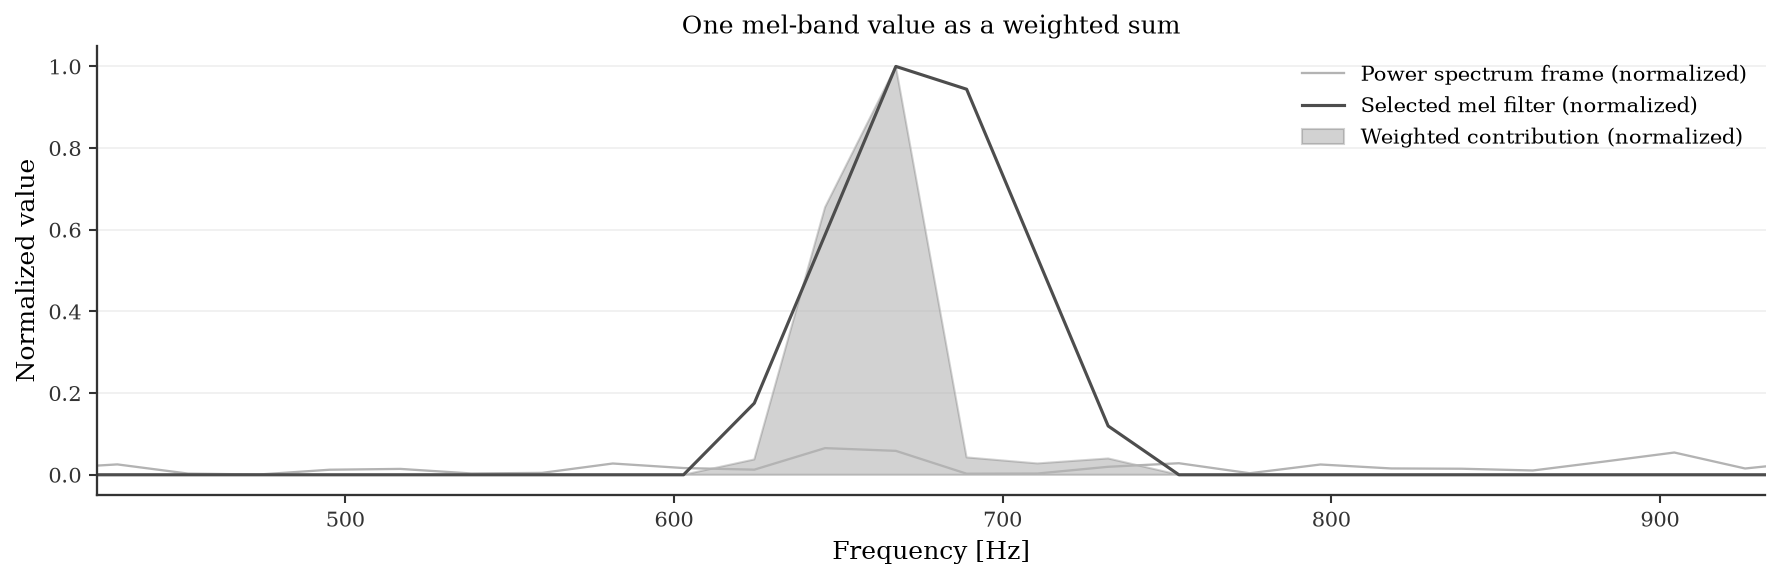

In [14]:
# Visualizing the weighted-sum operation

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE, dpi=DPI)

ax.plot(
    fft_frequencies,
    power_frame / power_frame.max(),
    color=GRAYSCALE["light"],
    linewidth=1.1,
    label="Power spectrum frame (normalized)",
)

ax.plot(
    fft_frequencies,
    mel_filter_weights / mel_filter_weights.max(),
    color=GRAYSCALE["secondary"],
    linewidth=1.5,
    label="Selected mel filter (normalized)",
)

ax.fill_between(
    fft_frequencies,
    weighted_terms / weighted_terms.max(),
    color=GRAYSCALE["secondary"],
    alpha=0.25,
    label="Weighted contribution (normalized)",
)

ax.set_title("One mel-band value as a weighted sum")
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("Normalized value")
ax.set_xlim(
    max(0, fft_frequencies[nonzero_bins[0]] - 200),
    min(sr / 2, fft_frequencies[nonzero_bins[-1]] + 200),
)

clean_axes(ax, grid_axis="y")
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

This small example shows exactly what the matrix multiplication does.

```text
filter weights × power spectrum values → weighted terms
sum of weighted terms                  → one mel-band energy
```

Repeating this for all mel filters gives one mel spectrum for the selected time frame.

Repeating it for all time frames gives the full mel-spectrogram.

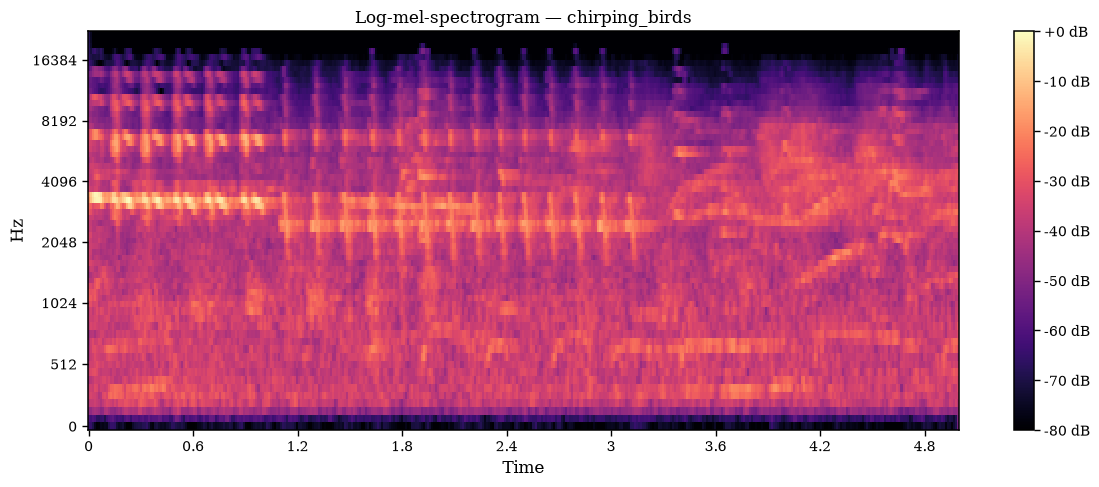

In [15]:
plt.figure(figsize=(12, 5))
librosa.display.specshow(
    log_mel_spectrogram,
    sr=sr,
    hop_length=hop_length,
    x_axis="time",
    y_axis="mel",
)
plt.colorbar(format="%+2.0f dB")
plt.title(f"Log-mel-spectrogram — {selected_category}")
plt.tight_layout()
plt.show()

## Spectral envelope

The **spectral envelope** is the broad, smooth shape of a spectrum.

It ignores very fine details and keeps the overall distribution of energy across frequency.

For speech and many environmental sounds, this broad spectral shape is very informative:

```text
fine spectral details       → rapid variations across frequency
broad spectral envelope     → slow variations across frequency
```

MFCCs are useful because the first coefficients mainly describe this broad envelope.

## From mel-band energy to frame-level energy

Before selecting one log-mel frame, it is useful to connect the notation with the previous notebook.

In the mel-spectrogram computation, we first obtain a short-time spectrum for each frame:

$
X[k,t]
$

where:

- $k$ is the FFT frequency-bin index,
- $t$ is the time-frame index.

The power spectrum is:

$
P[k,t] = |X[k,t]|^2
$

Then, the mel filter bank groups the power spectrum into mel-frequency bands:

$
S[m,t] = \sum_k H_m[k]P[k,t]
$

where:

- $H_m[k]$ is the weight of mel filter $m$ at FFT bin $k$,
- $S[m,t]$ is the energy assigned to mel band $m$ at frame $t$.

Therefore, the mel-spectrogram is a matrix:

```text
rows    → mel bands
columns → time frames
values  → mel-band energy
```

To estimate the total acoustic activity of a frame, we can sum all mel-band energies for that frame:

$
E[t] = \sum_{m=0}^{n_{\mathrm{mels}}-1} S[m,t]
$

In Python, this is:

```python
frame_energy = mel_spectrogram.sum(axis=0)
```

Here, `axis=0` means that we sum across the rows, producing one energy value for each time frame.

We use the linear mel-spectrogram for this step, not the log-mel-spectrogram, because energy values are easier to interpret before logarithmic compression.

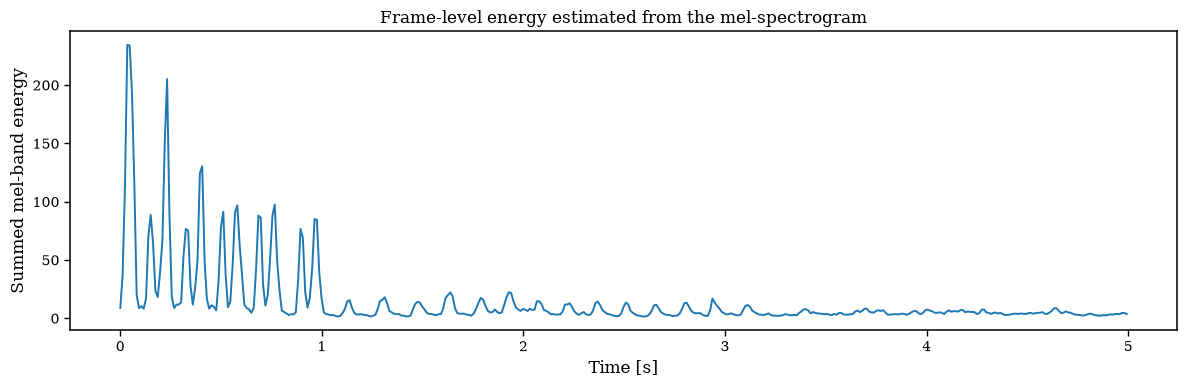

Number of frames: 431
Frame with minimum energy: 224
Frame with maximum energy: 3
Middle frame: 215


In [16]:
# Estimate frame-level energy from the linear mel-spectrogram.
# The mel_spectrogram matrix has shape: (n_mels, n_frames).
# Summing along axis=0 gives one energy value per time frame.

frame_energy = mel_spectrogram.sum(axis=0)

time_frames = librosa.frames_to_time(
    np.arange(log_mel_spectrogram.shape[1]),
    sr=sr,
    hop_length=hop_length,
)

plt.figure(figsize=(12, 4))
plt.plot(time_frames, frame_energy)
plt.title("Frame-level energy estimated from the mel-spectrogram")
plt.xlabel("Time [s]")
plt.ylabel("Summed mel-band energy")
plt.tight_layout()
plt.show()

print("Number of frames:", log_mel_spectrogram.shape[1])
print("Frame with minimum energy:", int(np.argmin(frame_energy)))
print("Frame with maximum energy:", int(np.argmax(frame_energy)))
print("Middle frame:", log_mel_spectrogram.shape[1] // 2)

## Inspecting a selected log-mel frame

A log-mel-spectrogram is a time-frequency representation.

Each column corresponds to one short time frame.  
Some frames may contain silence or low activity, while others may contain strong acoustic events.

In the next cell, you can choose which frame to inspect.

Try changing `frame_index` to:

```python
int(np.argmin(frame_energy))   # low-energy frame
int(np.argmax(frame_energy))   # high-energy frame
log_mel_spectrogram.shape[1] // 2   # middle frame
```

In [17]:
# Choose a frame to inspect.
# You can change this value manually.

frame_index = int(np.argmax(frame_energy))

# Make sure the selected frame is inside the valid range.
frame_index = int(np.clip(frame_index, 0, log_mel_spectrogram.shape[1] - 1))

log_mel_frame = log_mel_spectrogram[:, frame_index]
frame_time = time_frames[frame_index]

print("Selected frame index:", frame_index)
print("Approximate time:", f"{frame_time:.3f} seconds")
print("Frame energy:", frame_energy[frame_index])

Selected frame index: 3
Approximate time: 0.035 seconds
Frame energy: 234.45142


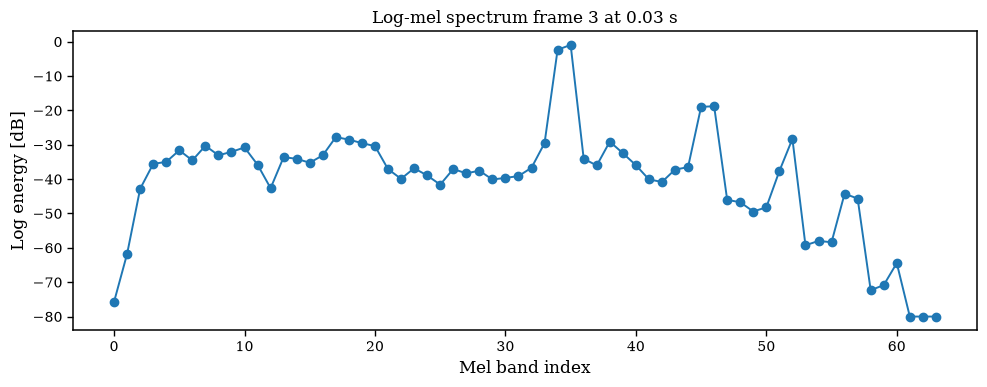

In [18]:
plt.figure(figsize=(10, 4))
plt.plot(np.arange(n_mels), log_mel_frame, marker="o")
plt.title(f"Log-mel spectrum frame {frame_index} at {frame_time:.2f} s")
plt.xlabel("Mel band index")
plt.ylabel("Log energy [dB]")
plt.tight_layout()
plt.show()

In [19]:
# Choose any frame to inspect.
# Valid range: 0 to log_mel_spectrogram.shape[1] - 1
# In this audio example, there are 431 frames, so valid indices are 0 to 430.

frame_index = 380  # change this value manually

# Make sure the selected frame is inside the valid range.
frame_index = int(np.clip(frame_index, 0, log_mel_spectrogram.shape[1] - 1))

log_mel_frame = log_mel_spectrogram[:, frame_index]
frame_time = time_frames[frame_index]

print("Number of frames:", log_mel_spectrogram.shape[1])
print("Valid frame range:", 0, "to", log_mel_spectrogram.shape[1] - 1)
print("Selected frame index:", frame_index)
print("Approximate time:", f"{frame_time:.3f} seconds")
print("Frame energy:", frame_energy[frame_index])

Number of frames: 431
Valid frame range: 0 to 430
Selected frame index: 380
Approximate time: 4.412 seconds
Frame energy: 3.1370888


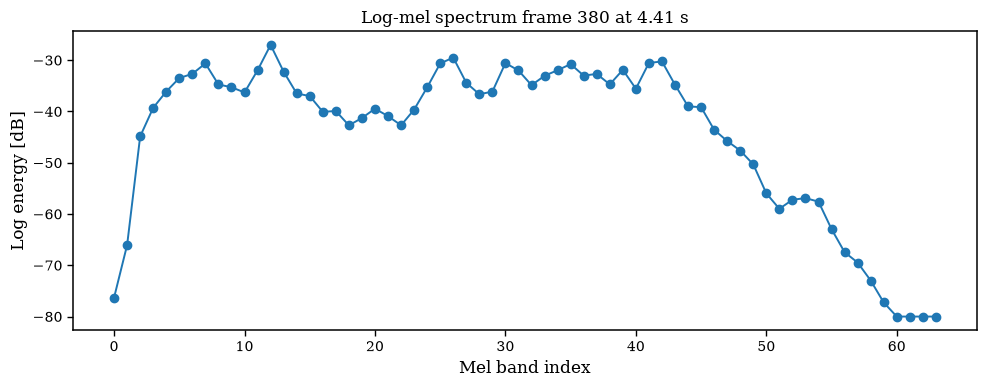

In [20]:
plt.figure(figsize=(10, 4))
plt.plot(np.arange(n_mels), log_mel_frame, marker="o")
plt.title(f"Log-mel spectrum frame {frame_index} at {frame_time:.2f} s")
plt.xlabel("Mel band index")
plt.ylabel("Log energy [dB]")
plt.tight_layout()
plt.show()

### Why introduce the cepstrum idea?

The log-mel spectrum still has one value per mel band.

The cepstral idea is to describe the **shape** of that spectrum using another set of coefficients.  
Low-order coefficients describe slow, broad variations; high-order coefficients describe fast, fine details.

This prepares the intuition for the DCT.

## Cepstrum intuition

The word **cepstrum** is historically derived by reversing part of the word “spectrum”.

At an intuitive level, cepstral analysis means:

```text
spectrum → logarithm → transform again
```

The goal is to describe the **shape** of the spectrum.

In many audio applications, cepstral analysis helps separate:

- slow variations in the spectral envelope;
- fast variations or fine spectral details.

For MFCCs, we do not compute the classical cepstrum directly from the linear spectrum.

Instead, we compute a **mel cepstral representation**:

```text
log-mel spectrum → Discrete Cosine Transform → mel-frequency cepstral coefficients
```

### Slow and fast variations across mel bands

Cepstral analysis is useful because it helps us think about two different types of variation in a spectrum.

A spectrum can have:

```text
slow variations → broad spectral envelope
fast variations → fine spectral details
```

In the MFCC context, these variations occur across the mel-frequency axis.

The following toy example illustrates the idea using a simple curve defined over mel bands.

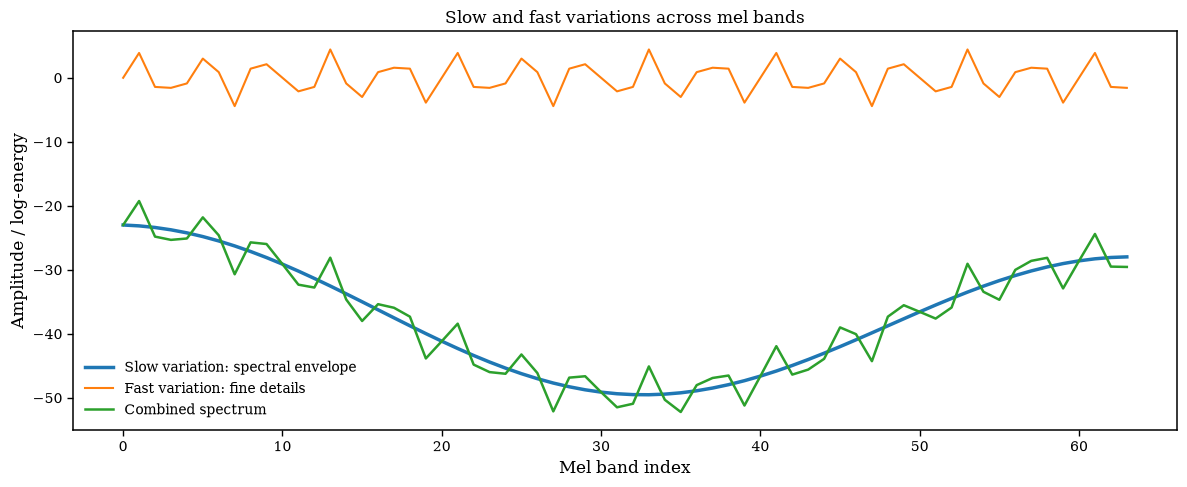

In [21]:
# Toy example: slow and fast variations across mel bands

mel_band_index = np.arange(n_mels)

slow_variation_demo = (
    -35
    + 12 * np.cos(2 * np.pi * mel_band_index / n_mels)
    - 5 * mel_band_index / n_mels
)

fast_variation_demo = (
    3.0 * np.sin(2 * np.pi * mel_band_index / 4)
    + 1.5 * np.sin(2 * np.pi * mel_band_index / 2.5)
)

combined_demo = slow_variation_demo + fast_variation_demo

plt.figure(figsize=(12, 5))
plt.plot(
    mel_band_index,
    slow_variation_demo,
    linewidth=2.5,
    label="Slow variation: spectral envelope",
)
plt.plot(
    mel_band_index,
    fast_variation_demo,
    linewidth=1.5,
    label="Fast variation: fine details",
)
plt.plot(
    mel_band_index,
    combined_demo,
    linewidth=1.8,
    label="Combined spectrum",
)

plt.title("Slow and fast variations across mel bands")
plt.xlabel("Mel band index")
plt.ylabel("Amplitude / log-energy")
plt.legend()
plt.tight_layout()
plt.show()

### Separating slow and fast variations with the DCT

The DCT represents a log-mel spectrum using cosine-shaped basis functions.

Low-order DCT coefficients correspond to slowly varying patterns across mel bands.  
High-order DCT coefficients correspond to rapidly varying patterns.

We can illustrate this idea using the selected real log-mel frame.

The experiment below reconstructs the log-mel frame using only a few low-order DCT coefficients.  
The difference between the original frame and the smooth reconstruction can be interpreted as fine spectral detail.

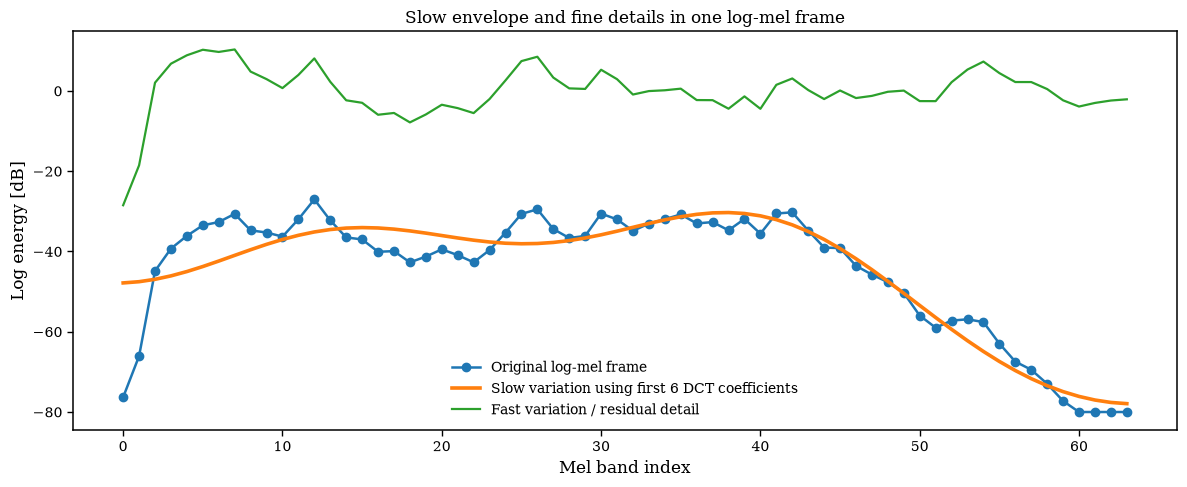

In [22]:
# DCT-based illustration of slow and fast variations in one real log-mel frame

mfcc_all_coefficients = dct(log_mel_frame, type=2, norm="ortho")

n_low_order = 6

mfcc_low_order = np.zeros_like(mfcc_all_coefficients)
mfcc_low_order[:n_low_order] = mfcc_all_coefficients[:n_low_order]

smooth_envelope_component = idct(mfcc_low_order, type=2, norm="ortho")
fine_detail_component = log_mel_frame - smooth_envelope_component

plt.figure(figsize=(12, 5))
plt.plot(
    np.arange(n_mels),
    log_mel_frame,
    marker="o",
    linewidth=1.8,
    label="Original log-mel frame",
)
plt.plot(
    np.arange(n_mels),
    smooth_envelope_component,
    linewidth=2.6,
    label=f"Slow variation using first {n_low_order} DCT coefficients",
)
plt.plot(
    np.arange(n_mels),
    fine_detail_component,
    linewidth=1.6,
    label="Fast variation / residual detail",
)

plt.title("Slow envelope and fine details in one log-mel frame")
plt.xlabel("Mel band index")
plt.ylabel("Log energy [dB]")
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation of slow and fast variations

The smooth curve captures the broad shape of the log-mel spectrum.  
This is the **spectral envelope**.

The residual curve captures the fine details that remain after removing the smooth component.

This illustrates the main intuition behind MFCCs:

```text
low-order MFCCs  → slow variations → broad spectral envelope
high-order MFCCs → fast variations → fine spectral details
```

This is also why many applications keep only the first 10–14 MFCC coefficients: they preserve much of the broad spectral-envelope information while discarding finer details that may be less robust.

## Discrete Cosine Transform

The Discrete Cosine Transform (DCT) represents a signal as a weighted sum of cosine-shaped basis functions.

In this notebook, the "signal" is not the audio waveform.  
The signal is one log-mel spectrum across mel bands.

```text
audio waveform → time-domain signal
one log-mel frame across bands → frequency-axis signal
```

Applying the DCT to a log-mel frame gives coefficients that describe how the log-mel spectrum varies across mel bands.

### Classical DCT expression

For a vector $x[n]$ of length $N$, the commonly used DCT-II can be written as:

$X[k] =\alpha(k)\sum_{n=0}^{N-1}x[n]\cos\left[\frac{\pi}{N}\left(n+\frac{1}{2}\right)k\right],\quad k = 0, 1, \ldots, N-1$

where:

$\alpha(k) =\begin{cases}\sqrt{\frac{1}{N}}, & k = 0 \\\sqrt{\frac{2}{N}}, & k> 0\end{cases}$

In the MFCC pipeline:

```text
x[n] → log-mel spectrum value at mel band n
X[k] → MFCC coefficient k
```

That is, the DCT takes one log-mel spectrum frame and represents it as a weighted sum of cosine-shaped basis functions.

The coefficient index \(k\) controls how rapidly the cosine basis varies across mel bands:

```text
small k → slowly varying basis → broad spectral envelope
large k → rapidly varying basis → fine spectral details
```

This is why the first MFCC coefficients are often associated with the global spectral shape.

### Interpreting the DCT formula

The DCT does not create new information.  
It rewrites the log-mel spectrum using a different coordinate system.

A useful way to think about it is:

```text
log-mel spectrum         → values across mel bands
DCT basis functions      → cosine patterns across mel bands
MFCC coefficients        → how much of each cosine pattern is needed
```

Therefore, each MFCC coefficient measures how strongly a particular cosine-shaped pattern is present in the log-mel spectrum.

This is conceptually similar to the Fourier Transform, but here the transform is applied to the **mel-frequency axis** of each short-time frame, not directly to the waveform in time.

## Visualizing DCT basis functions

The DCT uses cosine-shaped basis functions.

The first basis functions vary slowly across mel bands.  
Higher-index basis functions oscillate more rapidly.

This is why the first MFCC coefficients capture broad spectral shape, while later coefficients capture finer details.

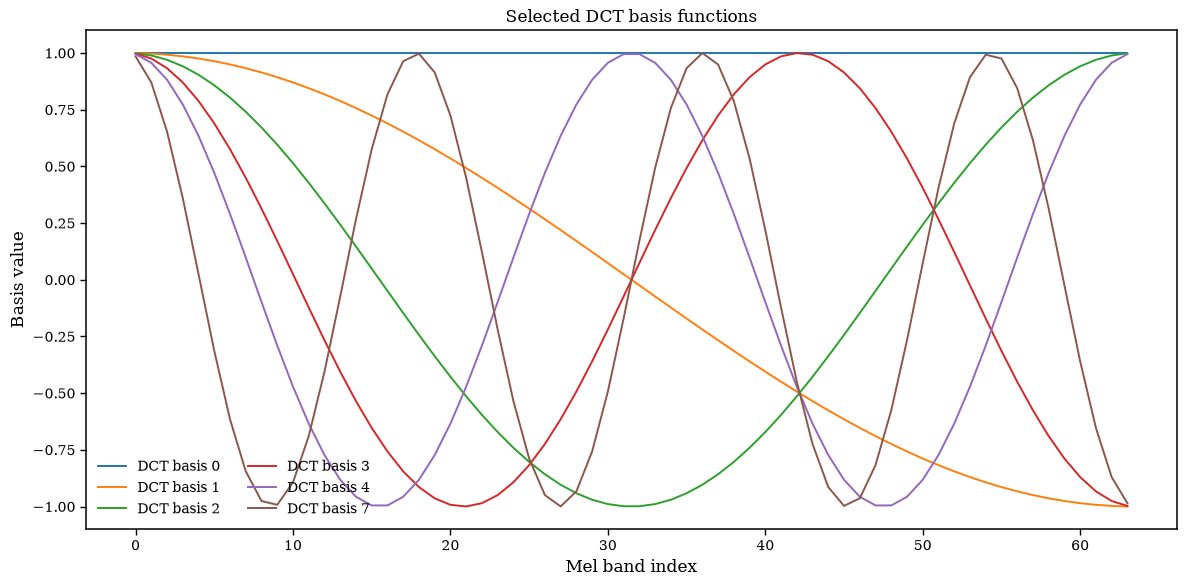

In [23]:
n_bands = n_mels
basis_indices = [0, 1, 2, 3, 4, 7] #[0, 1, 2, 3, 6, 10, 20, 30]

plt.figure(figsize=(12, 6))

for k in basis_indices:
    basis = np.cos(np.pi / n_bands * (np.arange(n_bands) + 0.5) * k)
    plt.plot(np.arange(n_bands), basis, label=f"DCT basis {k}")

plt.title("Selected DCT basis functions")
plt.xlabel("Mel band index")
plt.ylabel("Basis value")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

### DCT basis functions as a matrix

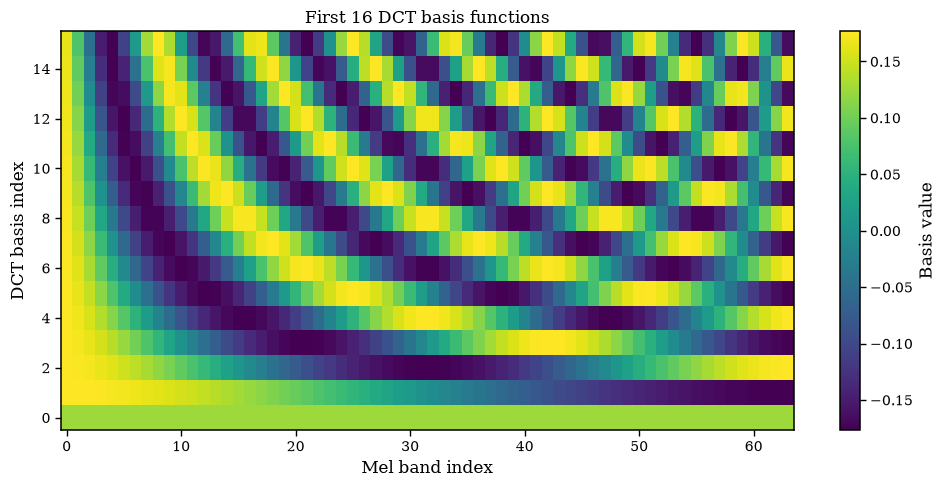

In [24]:
# Visualize DCT basis functions as a matrix

N = n_mels

dct_basis_matrix = np.zeros((N, N))

for k in range(N):
    alpha = np.sqrt(1 / N) if k == 0 else np.sqrt(2 / N)

    for n in range(N):
        dct_basis_matrix[k, n] = alpha * np.cos(
            np.pi / N * (n + 0.5) * k
        )

plt.figure(figsize=(10, 5))
plt.imshow(
    dct_basis_matrix[:16, :],
    aspect="auto",
    origin="lower",
    interpolation="nearest",
)
plt.colorbar(label="Basis value")
plt.title("First 16 DCT basis functions")
plt.xlabel("Mel band index")
plt.ylabel("DCT basis index")
plt.tight_layout()
plt.show()

### How to read the DCT basis matrix

Each row of the DCT basis matrix is a **template** or **pattern** that the DCT uses to describe the shape of a log-mel spectrum.

The horizontal axis is the mel-band index.  
The vertical axis is the DCT basis index.

A useful interpretation is:

```text
basis 0      → almost constant pattern
basis 1–3    → slow variations across mel bands
basis 10–15  → faster variations across mel bands
```

In other words:

- **basis 0** is almost constant, so it is related to the average level of the log-mel spectrum;
- **low-index bases** change slowly, so they capture broad spectral-envelope information;
- **high-index bases** oscillate more rapidly, so they capture finer spectral details.

This is why the first MFCC coefficients are often the most useful ones:

```text
low-order MFCCs  → broad spectral envelope
high-order MFCCs → fine spectral details
```

A simple way to say it is:

> Each DCT coefficient measures how much the log-mel spectrum resembles one of these cosine-shaped patterns.

In the matrix view above:

```text
rows    → DCT basis functions
columns → mel band indices
values  → cosine basis values
```

The lower-index rows vary slowly across mel bands.  
The higher-index rows oscillate more rapidly.

This visualizes why low-order MFCCs summarize broad spectral-envelope information, while higher-order MFCCs capture finer spectral variations.

### Important axis interpretation

The DCT for MFCCs is applied **across mel bands**, not across time samples of the waveform.

For a fixed time frame:

```text
mel band index → input axis for the DCT
MFCC index     → output coefficient index
```

This is why MFCCs summarize the shape of each log-mel spectrum.

## Applying DCT to one log-mel frame

Now we apply the DCT to one log-mel spectrum frame.

The result is a vector of cepstral coefficients.

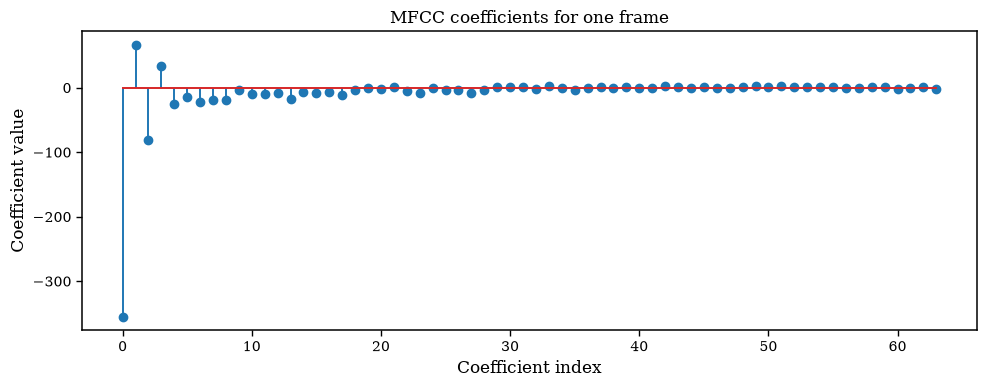

In [25]:
mfcc_frame = dct(log_mel_frame, type=2, norm="ortho")

plt.figure(figsize=(10, 4))
plt.stem(np.arange(len(mfcc_frame)), mfcc_frame)
plt.title("MFCC coefficients for one frame")
plt.xlabel("Coefficient index")
plt.ylabel("Coefficient value")
plt.tight_layout()
plt.show()

## Why keep only the first 10–14 coefficients?

The first MFCC coefficients describe slow, broad variations of the log-mel spectrum.

These low-order coefficients capture the overall spectral envelope, which is often useful for classification and recognition tasks.

Higher-order coefficients describe faster variations across mel bands.  
They may contain fine detail, but they are often less robust and more sensitive to noise.

This is why many audio applications keep only a small number of MFCCs, such as 13 coefficients.

## Reconstructing an approximate log-mel frame

To see what the first MFCC coefficients preserve, we can reconstruct the log-mel frame using only a few low-order coefficients.

This reconstruction is only for visualization.

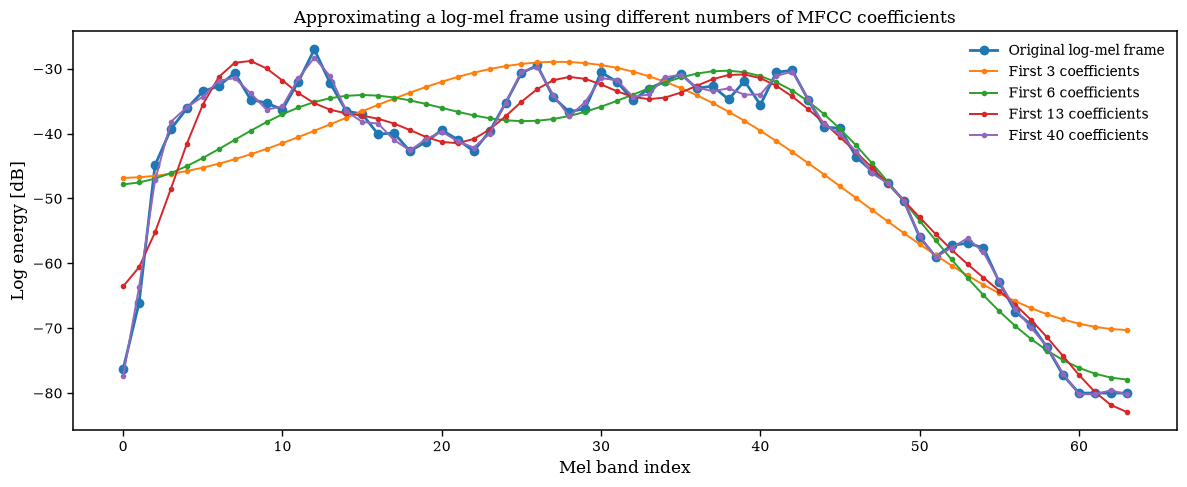

In [26]:
def reconstruct_from_first_coefficients(coefficients, n_keep):
    """
    Reconstruct an approximate log-mel frame using only the first n_keep DCT coefficients.
    """
    truncated = np.zeros_like(coefficients)
    truncated[:n_keep] = coefficients[:n_keep]
    reconstructed = idct(truncated, type=2, norm="ortho")
    return reconstructed


n_keep_values = [3, 6, 13, 40]

plt.figure(figsize=(12, 5))
plt.plot(log_mel_frame, marker="o", linewidth=2, label="Original log-mel frame")

for n_keep in n_keep_values:
    reconstructed = reconstruct_from_first_coefficients(mfcc_frame, n_keep)
    plt.plot(reconstructed, marker=".", label=f"First {n_keep} coefficients")

plt.title("Approximating a log-mel frame using different numbers of MFCC coefficients")
plt.xlabel("Mel band index")
plt.ylabel("Log energy [dB]")
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation

Using only a few coefficients preserves the broad spectral shape.

As we keep more coefficients, the reconstruction captures finer details.

This illustrates why the first MFCC coefficients are often useful: they summarize the global spectral envelope compactly.

## Computing MFCCs with librosa

In practice, we can compute MFCCs directly with `librosa.feature.mfcc`.

The output is a matrix:

```text
rows    → MFCC coefficients
columns → time frames
values  → MFCC coefficient values
```

In [27]:
n_mfcc = 13

mfcc = librosa.feature.mfcc(
    y=y,
    sr=sr,
    n_mfcc=n_mfcc,
    n_mels=n_mels,
    n_fft=n_fft,
    hop_length=hop_length,
)

print("MFCC shape:", mfcc.shape)

MFCC shape: (13, 431)


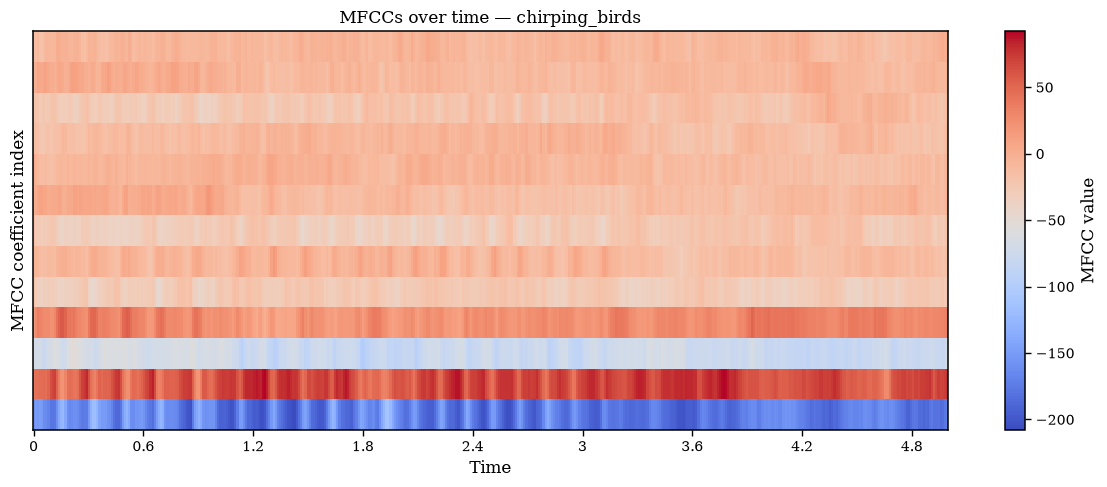

In [28]:
plt.figure(figsize=(12, 5))
librosa.display.specshow(
    mfcc,
    x_axis="time",
    sr=sr,
    hop_length=hop_length,
)
plt.colorbar(label="MFCC value")
plt.title(f"MFCCs over time — {selected_category}")
plt.ylabel("MFCC coefficient index")
plt.tight_layout()
plt.show()

## MFCCs as time-varying features

MFCCs are computed for short frames, just like the STFT and mel-spectrogram.

Therefore, each coefficient changes over time.

We can inspect each MFCC trajectory.

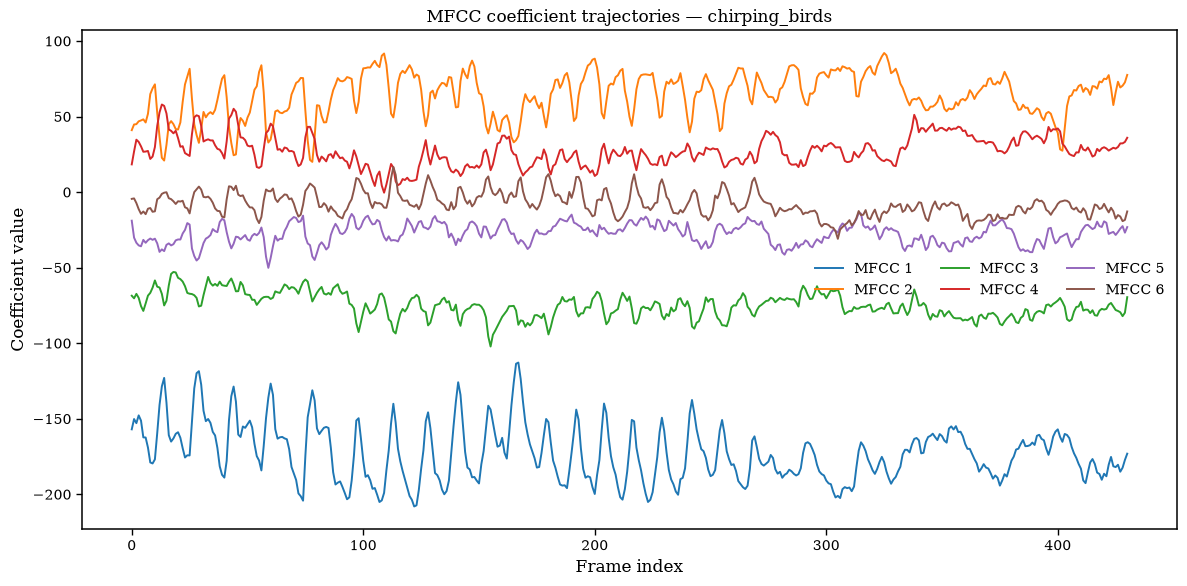

In [38]:
plt.figure(figsize=(12, 6))

n_mfcc_ = 6
for i in range(n_mfcc_):
    plt.plot(mfcc[i], label=f"MFCC {i + 1}")

plt.title(f"MFCC coefficient trajectories — {selected_category}")
plt.xlabel("Frame index")
plt.ylabel("Coefficient value")
plt.legend(ncol=3)
plt.tight_layout()
plt.show()

## From MFCC sequences to tabular features

MFCCs are computed frame by frame, so one audio file produces a matrix:

```text
MFCC coefficient index × time frame
```

Many traditional machine-learning models expect one feature vector per audio file.  
A simple way to obtain this is to summarize each coefficient over time using statistics such as the mean and standard deviation.

## MFCC summary features

For machine learning with tabular data, we often summarize each coefficient over time.

For example, for each MFCC coefficient we can compute:

- mean;
- standard deviation.

This transforms a time-varying MFCC matrix into a fixed-length feature vector.

In [30]:
mfcc_summary = {}

for i in range(n_mfcc):
    mfcc_summary[f"mfcc_{i + 1}_mean"] = np.mean(mfcc[i])
    mfcc_summary[f"mfcc_{i + 1}_std"] = np.std(mfcc[i])

mfcc_summary_df = pd.DataFrame([mfcc_summary])
mfcc_summary_df

,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,mfcc_4_std,mfcc_5_mean,mfcc_5_std,...,mfcc_9_mean,mfcc_9_std,mfcc_10_mean,mfcc_10_std,mfcc_11_mean,mfcc_11_std,mfcc_12_mean,mfcc_12_std,mfcc_13_mean,mfcc_13_std
0,-172.66626,18.455114,63.966793,14.397439,-75.065941,8.053144,27.192448,9.790486,-27.57473,6.594799,...,-7.782007,6.006305,-9.947284,6.522583,-19.372381,8.176607,-6.345053,6.70828,-7.239656,4.829298


## Compare MFCCs across classes

Now we compute MFCC summary features for all files in the ESC-50 subset.

This allows us to compare the average MFCC patterns across sound classes.

In [31]:
def compute_mfcc_summary(audio_path, sr_target=None, n_mfcc=13, n_mels=40, n_fft=2048, hop_length=512):
    """
    Compute mean and standard deviation of MFCC coefficients for one audio file.
    """
    y_tmp, sr_tmp = librosa.load(audio_path, sr=sr_target, mono=True)

    mfcc_tmp = librosa.feature.mfcc(
        y=y_tmp,
        sr=sr_tmp,
        n_mfcc=n_mfcc,
        n_mels=n_mels,
        n_fft=n_fft,
        hop_length=hop_length,
    )

    features = {}

    for i in range(n_mfcc):
        features[f"mfcc_{i + 1}_mean"] = np.mean(mfcc_tmp[i])
        features[f"mfcc_{i + 1}_std"] = np.std(mfcc_tmp[i])

    return features


rows = []

for _, row in tqdm(metadata.iterrows(), total=len(metadata), desc="Computing MFCC summaries"):
    audio_path = PROJECT_ROOT / row["subset_audio_path"]

    features = compute_mfcc_summary(
        audio_path,
        sr_target=None,
        n_mfcc=n_mfcc,
        n_mels=n_mels,
        n_fft=n_fft,
        hop_length=hop_length,
    )

    output_row = {
        "filename": row["filename"],
        "category": row["category"],
    }

    output_row.update(features)
    rows.append(output_row)

mfcc_features = pd.DataFrame(rows)

print("MFCC feature table shape:", mfcc_features.shape)

mfcc_features.head()

Computing MFCC summaries: 100%|██████████| 80/80 [00:00<00:00, 106.01it/s]

MFCC feature table shape: (80, 28)


,filename,category,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,mfcc_4_std,...,mfcc_9_mean,mfcc_9_std,mfcc_10_mean,mfcc_10_std,mfcc_11_mean,mfcc_11_std,mfcc_12_mean,mfcc_12_std,mfcc_13_mean,mfcc_13_std
0,1-100038-A-14.wav,chirping_birds,-172.666260,18.455114,63.966793,14.397439,-75.065941,8.053144,27.192448,9.790486,...,-7.782007,6.006305,-9.947284,6.522583,-19.372381,8.176607,-6.345053,6.708280,-7.239656,4.829298
1,1-34495-A-14.wav,chirping_birds,-152.789581,14.111407,47.917309,5.137900,-13.582367,14.782961,8.128170,8.469433,...,-3.808345,6.091858,16.375866,7.542896,-4.692681,6.137853,1.347813,6.492510,-9.049219,5.068076
2,1-34497-A-14.wav,chirping_birds,-150.350464,6.281711,43.457966,3.603483,-8.537961,7.603381,17.289671,6.103340,...,-9.522822,6.496200,11.484612,5.464473,-9.667860,5.501277,6.218293,5.311808,-13.344412,4.737608
3,1-38559-A-14.wav,chirping_birds,-309.286407,25.233599,39.889618,9.046180,-66.449669,26.869726,12.110153,8.180028,...,-14.747070,5.130711,7.446472,7.068198,-13.687717,4.767821,-0.463011,5.822233,-9.845196,5.774426
4,1-38560-A-14.wav,chirping_birds,-338.645630,34.513279,30.210381,13.168006,-42.890961,34.797035,8.496633,20.036940,...,-13.593718,8.450089,0.477728,5.746286,-11.669695,6.278904,3.983445,4.421641,-10.880406,5.750299


## Average MFCC pattern by class

We can group the feature table by class and inspect the average MFCC values.

In [32]:
mfcc_mean_columns = [f"mfcc_{i + 1}_mean" for i in range(n_mfcc)]

class_mfcc_means = (
    mfcc_features
    .groupby("category")[mfcc_mean_columns]
    .mean()
)

class_mfcc_means

,mfcc_1_mean,mfcc_2_mean,mfcc_3_mean,mfcc_4_mean,mfcc_5_mean,mfcc_6_mean,mfcc_7_mean,mfcc_8_mean,mfcc_9_mean,mfcc_10_mean,mfcc_11_mean,mfcc_12_mean,mfcc_13_mean
category,,,,,,,,,,,,,
chirping_birds,-231.895920,67.031937,-27.862591,19.613916,-11.573337,0.709846,-12.534095,0.182924,-12.647224,5.812562,-10.379452,1.602443,-9.362022
clock_tick,-372.237732,79.060417,0.502808,16.996937,0.804119,10.797444,0.250214,6.392775,-2.226342,1.913121,-1.331475,1.942432,-0.524292
dog,-309.328064,68.220100,-5.197465,-9.401175,-9.846056,-4.789180,-6.025416,-3.708651,-0.938465,-2.740333,-2.190529,-0.597745,0.303651
helicopter,-98.953026,113.548782,-16.630142,31.079935,-12.466509,18.965733,-5.197593,8.580506,-7.299685,9.085417,-3.574623,2.991027,-1.729137
keyboard_typing,-310.091614,60.087635,-7.328963,20.800158,-0.117214,13.054097,-1.766105,10.711084,0.781083,6.587611,1.011785,4.872531,-0.855389
rain,-80.771645,90.211540,-61.563557,41.199890,-23.215534,16.924124,-9.652987,6.981261,-4.153660,7.377867,-6.761366,6.318498,-4.858619
sea_waves,-91.699631,102.431602,-30.451706,21.056492,-23.271774,17.602337,-21.263554,11.702839,-14.018740,5.734509,-8.502946,3.278295,-6.017835
sneezing,-384.454865,20.700878,-3.659693,4.564864,-1.151298,1.998751,-2.331937,-0.236016,-0.744072,0.402317,-0.400617,-0.509319,-0.651698


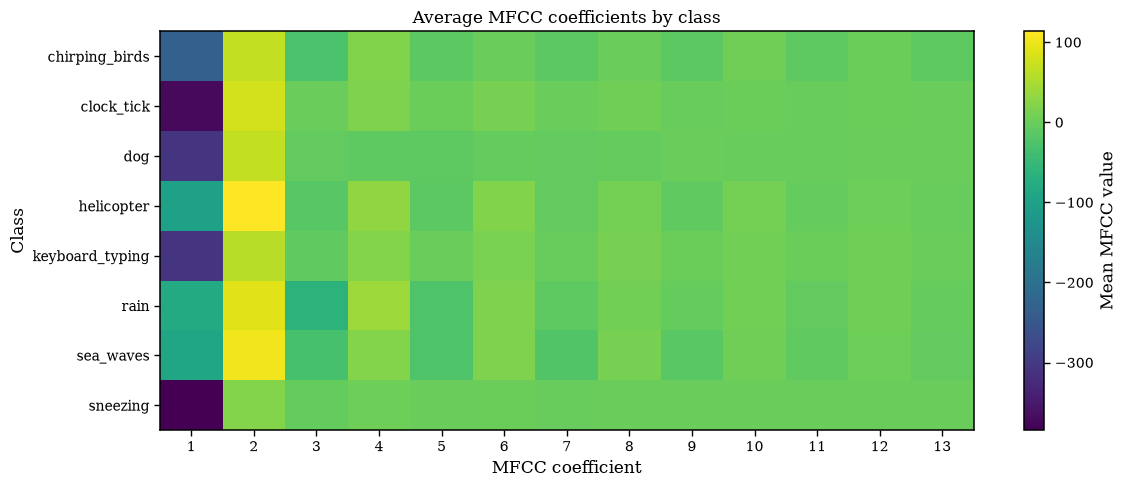

In [33]:
plt.figure(figsize=(12, 5))
plt.imshow(class_mfcc_means.values, aspect="auto")
plt.colorbar(label="Mean MFCC value")
plt.title("Average MFCC coefficients by class")
plt.xlabel("MFCC coefficient")
plt.ylabel("Class")
plt.xticks(
    ticks=np.arange(n_mfcc),
    labels=[str(i + 1) for i in range(n_mfcc)]
)
plt.yticks(
    ticks=np.arange(len(class_mfcc_means.index)),
    labels=class_mfcc_means.index
)
plt.tight_layout()
plt.show()

## Optional: delta and delta-delta MFCCs

MFCCs describe the spectral envelope at each time frame.

It is also common to compute:

- **delta MFCCs**, which describe how MFCCs change over time;
- **delta-delta MFCCs**, which describe how the changes themselves vary over time.

These are often used in speech and audio classification.

A useful interpretation is:

```text

MFCCs        → spectral-envelope shape

Delta MFCCs  → temporal change of that shape

Delta-delta  → acceleration of that temporal change

In [34]:
delta_mfcc = librosa.feature.delta(mfcc)
delta2_mfcc = librosa.feature.delta(mfcc, order=2)

print("MFCC shape:", mfcc.shape)
print("Delta MFCC shape:", delta_mfcc.shape)
print("Delta-delta MFCC shape:", delta2_mfcc.shape)

MFCC shape: (13, 431)
Delta MFCC shape: (13, 431)
Delta-delta MFCC shape: (13, 431)


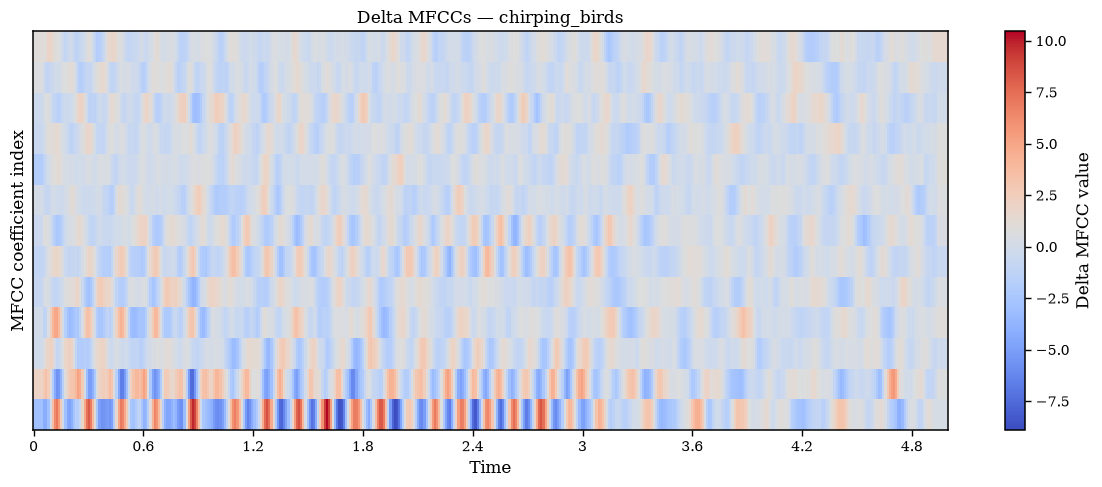

In [35]:
plt.figure(figsize=(12, 5))
librosa.display.specshow(
    delta_mfcc,
    x_axis="time",
    sr=sr,
    hop_length=hop_length,
)
plt.colorbar(label="Delta MFCC value")
plt.title(f"Delta MFCCs — {selected_category}")
plt.ylabel("MFCC coefficient index")
plt.tight_layout()
plt.show()

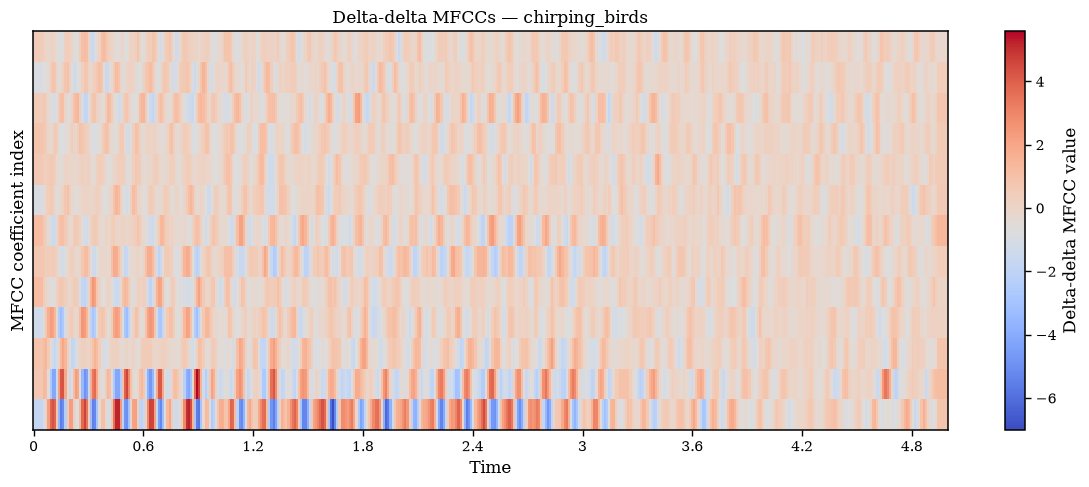

In [39]:
plt.figure(figsize=(12, 5))

librosa.display.specshow(
    delta2_mfcc,
    x_axis="time",
    sr=sr,
    hop_length=hop_length,
)

plt.colorbar(label="Delta-delta MFCC value")
plt.title(f"Delta-delta MFCCs — {selected_category}")
plt.ylabel("MFCC coefficient index")
plt.tight_layout()
plt.show()

## Summary

In this notebook, we moved from log-mel-spectrograms to MFCCs.

The main sequence was:

```text
audio
    ↓
STFT
    ↓
mel-spectrogram
    ↓
log-mel-spectrogram
    ↓
DCT across mel bands
    ↓
MFCCs
    ↓
summary statistics for machine learning
```

The main interpretation is:

```text
low-order MFCCs  → broad spectral envelope
high-order MFCCs → fine spectral details
```

MFCCs are therefore compact, interpretable descriptors of the shape of the log-mel spectrum.

## Discussion questions

1) Why are MFCCs computed from the log-mel spectrum rather than directly from the waveform?
2) What is the difference between a log-mel-spectrogram and MFCCs?
3) What does the DCT do in the MFCC pipeline?
4) Why do the first MFCC coefficients capture broad spectral information?
5) Why might high-order MFCC coefficients be less robust?
6) How could MFCC mean and standard deviation be used in an audio classification model?